In [1]:
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

os.chdir(r'D:\Work\景观格局指标对PM2.5影响')

df = pd.read_excel("样本数据.xlsx", header=1, index_col=0)

In [2]:
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.model_selection import cross_val_score
import numpy as np

In [3]:
import shap
shap.initjs()

data = df.iloc[:, :-4]
targets = df.iloc[:, -4:]
target_names = targets.columns

In [9]:
target_name = target_names[0]
target = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    data, target, train_size=0.8, test_size=0.2, random_state=925) 

In [ ]:
model = GradientBoostingRegressor(
    random_state=925,
    max_depth=10
)

param_dist = {
    'learning_rate': uniform(0.01, 0.3),  # 0.01~0.3均匀采样
    'n_estimators': randint(100, 2000),      # 50~500随机整数
}

model = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    model, param_dist, n_iter=20, cv=5, 
    scoring='neg_mean_squared_error'
)
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

In [29]:
gbr = GradientBoostingRegressor(
    learning_rate=0.001,
    n_estimators=500,
    n_iter_no_change=50,
    max_depth=10,
    random_state=925,
)
gbr.fit(X_train, y_train)

scores = cross_val_score(
    gbr,
    X_test, y_test,
    cv=5, scoring='neg_mean_squared_error'
)
print("RMSE: ", np.sqrt(-scores.mean()))

RMSE:  7.9674181411365685


In [78]:
explainer = shap.Explainer(gbr)
shap_values = explainer.shap_values(X_test)

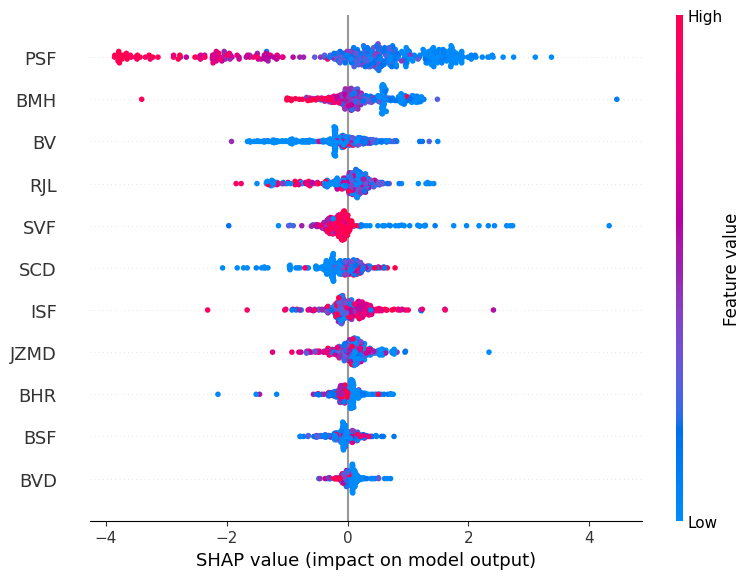

In [79]:
shap.summary_plot(shap_values, X_test)

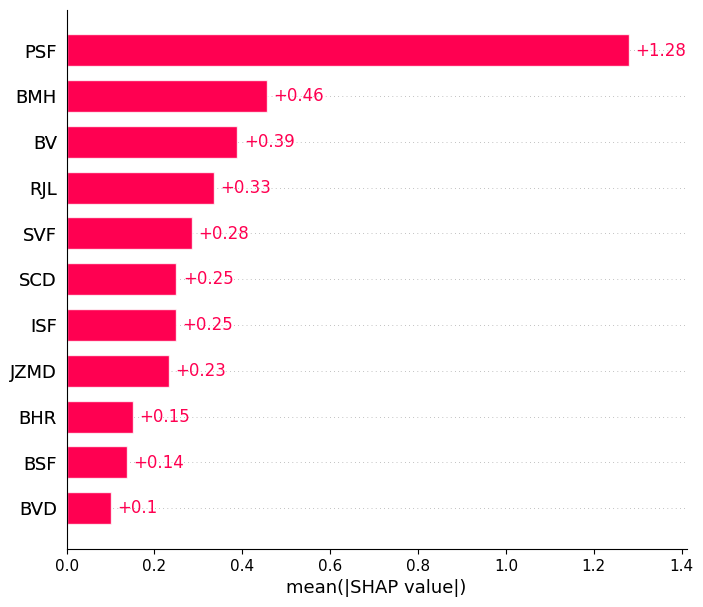

In [60]:
shap.plots.bar(shap_values, max_display=20)

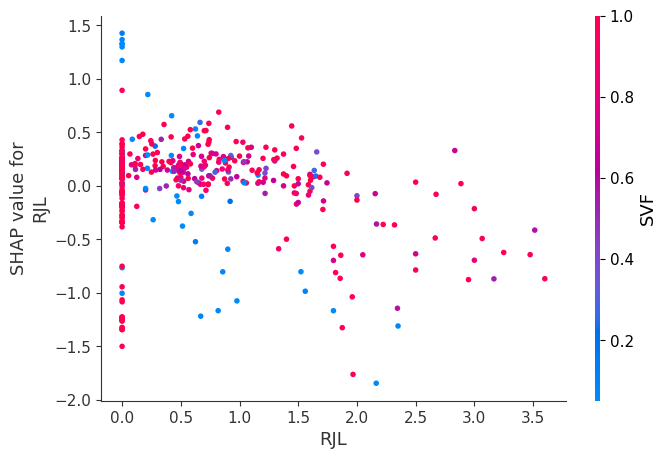

In [84]:
shap.dependence_plot('RJL', shap_values, X_test)